In [1]:
# The first step: Sample and shuffle the open data source. The name of open dataset is fake reviews and dataset.
import pandas as pd

# 1. Read the original large dataset.
df = pd.read_csv(r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\fake reviews dataset.csv')

print(f"Size of the original dataset: {df.shape}")

# 2. Randomly shuffle and extract 3,000 items.
df_subset = df.sample(n=3000, random_state=42)

# 3. Reset the index
df_subset = df_subset.reset_index(drop=True)

print(f"Size of the new dataset: {df_subset.shape}")

# 4. Save as a new file
# index=False: The representative does not save these index numbers such as 0, 1, 2... into the CSV file.
df_subset.to_csv(r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\open_3k.csv', index=False, encoding='utf-8-sig')

print("Saved successfully!")

Size of the original dataset: (40432, 4)
Size of the new dataset: (3000, 4)
Saved successfully!


In [2]:
# The second step: Clean the dataset we collected ourselves.
import pandas as pd

# 1. Define the file path
input_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\self_dataset.csv'
output_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\self_dataset_cleaned.csv'

# 2. reading data
# Prevent errors when reading, encoding='utf-8' or encoding='latin1'
df = pd.read_csv(input_path)

# Core step: Select and reorder the data columns
target_columns = ['category', 'rating', 'label', 'text']

try:
    df_cleaned = df[target_columns].copy()

    # Text cleaning: Eliminating the risk of garbled characters
    # 1. Make sure it is a string
    df_cleaned['text'] = df_cleaned['text'].fillna('').astype(str)

    # 2. Replace the curved quotation marks with straight ones
    df_cleaned['text'] = df_cleaned['text'].str.replace('’', "'", regex=False)

    # 3. save the file
    # encoding='utf-8-sig'
    df_cleaned.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"Successful processing!")
    print(f"The file has been saved to: {output_path}")

    # 打印一条包含引号的数据看看效果
    print("Preview: ")
    print(df_cleaned[df_cleaned['text'].str.contains("'")].head(1)['text'].values)

except KeyError as e:
    print(f"Error: Missing columns {e}")

Successful processing!
The file has been saved to: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\self_dataset_cleaned.csv
Preview: 
["Berne has good products, better than Carhartt in my opinion.  Not because of any political BS just because of price and weight.  Everything from Carhartt weighs a ton to be warm while everything from Berne is light and warm at the same time.  We've worn their winter bibs for years now, and they last much longer. On to the shirts, they are lightweight, warm, and have a handy pocket over the left pec.  These shirts have been through the gauntlet at my house already, and with a little pre treat the stains come right out.  Soft and comfortable which my husband loves!  Berne has a great product."]


In [3]:
# The third step: Merge the open dataset and self-dataset.
import pandas as pd

# 1. Define the file path
file1_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\open_3k.csv'
file2_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\self_dataset_cleaned.csv'
output_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset.csv'

# 2. Read two CSV files
# Use utf-8-sig to ensure that previous special characters can be read correctly
df1 = pd.read_csv(file1_path, encoding='utf-8-sig')
df2 = pd.read_csv(file2_path, encoding='utf-8-sig')

print(f"The shape of file 1: {df1.shape}")
print(f"The shape of file 2: {df2.shape}")

# 3. Check whether the column names are exactly the same
if list(df1.columns) != list(df2.columns):
    print("⚠️ Warning: If the column name order or names of two files are not exactly the same, pandas will attempt to align and merge them by column name.")
    print(f"File 1 column name: {list(df1.columns)}")
    print(f"File 2 column name: {list(df2.columns)}")
else:
    print("✅ The listing check has passed and the format is consistent.")

# 4. Merging data
# ignore_index=True is equivalent to automatic execution reset_index(drop=True)
# It will ignore the indexes of the original two tables and regenerate 0, 1, 2, 3... The new index
df_merged = pd.concat([df1, df2], ignore_index=True)

print(f"The total size after merging: {df_merged.shape}")

# 5. Save as a new file
df_merged.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Saved successfully! The merged file is located at: {output_path}")

The shape of file 1: (3000, 4)
The shape of file 2: (1000, 4)
✅ The listing check has passed and the format is consistent.
The total size after merging: (4000, 4)
Saved successfully! The merged file is located at: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset.csv


In [4]:
# The forth step: Featurization.
import pandas as pd

# 1. Read the data
input_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset.csv'
df = pd.read_csv(input_path)

# Preprocessing: Ensure that the text column is a string and handle null values
df['text'] = df['text'].fillna('').astype(str)

# Feature engineering: Calculate features and add them to new columns

# 1. Basic length characteristics
# Word Count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 2. Punctuation mark features
df['excl_count'] = df['text'].apply(lambda x: x.count('!'))

# View the results
print("Preview of the features of the first 5 lines of data: ")
print(df[['label', 'text', 'word_count', 'excl_count']].head())

# Simply verify the validity of features
# We can take a look at the average differences between CG (false) and OR (true) in these features
print("\nComparison of the mean values of features in different categories: ")
print(df.groupby('label')[['word_count', 'excl_count']].mean())

# Save the result to a CSV file
# Save it as a new file name to distinguish the original data
output_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset_with_features.csv'

# index=False Represents not saving row indexes (0,1,2...) Only save the data columns
df.to_csv(output_path, index=False)

print(f"\nSuccess! The new feature has been saved to the file:{output_path}")

Preview of the features of the first 5 lines of data: 
  label                                               text  word_count  \
0    CG  Eva is on her to find a way to escape her abus...         183   
1    CG  This is my second Glamorise and I love the loo...          81   
2    OR  I absolutely love this series. The Ravens are ...          32   
3    CG  Probably best movie Rutger Howerton has made. ...          37   
4    OR  Unfortunately the black didn't work for a lot ...          57   

   excl_count  
0           2  
1           1  
2           0  
3           0  
4           1  

Comparison of the mean values of features in different categories: 
       word_count  excl_count
label                        
CG      52.668342    0.190452
OR      67.961194    0.514925

Success! The new feature has been saved to the file:C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset_with_features.csv


In [5]:
# The fifth step: Split dataset FIRST to prevent data leakage.
import pandas as pd
import numpy as np
import os

# 1. Read the file containing the basic features (this is generated in the fourth step).
input_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\merged_dataset_with_features.csv'
df = pd.read_csv(input_path)

# Simple null value handling
df['text'] = df['text'].fillna('').astype(str)

print(f"Size of the original dataset: {df.shape}")

# 2. Randomly shuffle and split (80% for training, 20% for testing)
# Set a random seed to ensure reproducibility
np.random.seed(42)

# Generate random index
indices = np.random.permutation(len(df))
test_size = int(len(df) * 0.2)

test_indices = indices[:test_size]
train_indices = indices[test_size:]

# Split DataFrame
df_train = df.iloc[train_indices].reset_index(drop=True)
df_test = df.iloc[test_indices].reset_index(drop=True)

print(f"Size of the training set: {df_train.shape}")
print(f"Size of the test set: {df_test.shape}")

# 3. Save the original data that has been split (Raw Split Data)
train_save_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_raw.csv'
test_save_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_raw.csv'

df_train.to_csv(train_save_path, index=False)
df_test.to_csv(test_save_path, index=False)

print(f"\n✅ The dataset has been split and saved!")
print(f"Training set: {train_save_path}")
print(f"Test set: {test_save_path}")

Size of the original dataset: (4000, 6)
Size of the training set: (3200, 6)
Size of the test set: (800, 6)

✅ The dataset has been split and saved!
Training set: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_raw.csv
Test set: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_raw.csv


In [6]:
# The sixth step: TF-IDF and SVD (Fit on Train, Transform Test)
import pandas as pd
import numpy as np
import re
from collections import Counter
import pickle # Used for storing IDF and SVD parameters

# 1. Read the segmented data
df_train = pd.read_csv(r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_raw.csv')
df_test = pd.read_csv(r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_raw.csv')

# Ensure that the text is presented as a string.
df_train['text'] = df_train['text'].fillna('').astype(str)
df_test['text'] = df_test['text'].fillna('').astype(str)

print("Feature processing is underway....")

# ==========================================
# Stage 1: Build the vocabulary (based solely on the training set!)
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# 1.1 Build the Corpus solely using the training set
train_docs_tokens = df_train['text'].apply(clean_text).tolist()

vocab_size = 3000
all_words = [word for doc in train_docs_tokens for word in doc]
# Select the 3000 most common words from the training set
most_common_words = [word for word, count in Counter(all_words).most_common(vocab_size)]
word_to_index = {word: i for i, word in enumerate(most_common_words)}
n_vocab = len(word_to_index)

print(f"The word list has been constructed (based solely on the training set), and the size of the word list is: {n_vocab}")

# ==========================================
# Stage 2: Calculate TF-IDF
# ==========================================

def compute_tf_matrix(docs_tokens, word_to_idx, n_v):
    """Calculating the TF matrix"""
    n_d = len(docs_tokens)
    tf_mat = np.zeros((n_d, n_v))
    # The document frequency statistics used for calculating IDF (required only when processing the training set, but returned first in the function)
    doc_freqs = np.zeros(n_v)

    for i, tokens in enumerate(docs_tokens):
        counts = Counter(tokens)
        total = len(tokens)
        if total == 0: continue

        seen = set()
        for w, c in counts.items():
            if w in word_to_idx:
                idx = word_to_idx[w]
                tf_mat[i, idx] = c / total
                seen.add(idx)

        for idx in seen:
            doc_freqs[idx] += 1

    return tf_mat, doc_freqs

# 2.1 Processing the training set
print("The TF-IDF of the training set is being calculated....")
tf_train, doc_freq_train = compute_tf_matrix(train_docs_tokens, word_to_index, n_vocab)

# Calculate IDF (using only the document distribution of the training set)
n_train = len(df_train)
idf_vector = np.log(n_train / (doc_freq_train + 1)) # +1 Smoothing

# Obtain the training set TF-IDF
tfidf_train = tf_train * idf_vector

# 2.2 Processing the test set. It is a key step to prevent data leakage.
# Key point：The test set must use the word_to_index and idf_vector from the training set.
print("Currently, the test set is being converted to TF-IDF (using the rules from the training set)...")
test_docs_tokens = df_test['text'].apply(clean_text).tolist()
# Calculate the test set TF
tf_test, _ = compute_tf_matrix(test_docs_tokens, word_to_index, n_vocab)

# Multiply the IDF of the training set by the TF of the test set
tfidf_test = tf_test * idf_vector

# ==========================================
# Stage 3: SVD Dimensionality Reduction
# ==========================================
k = 24
print(f"The SVD dimension reduction is currently in progress (k={k})...")

# 3.1 Fit on the training set
# Training set matrix: M = U * Sigma * Vt
U, Sigma, Vt = np.linalg.svd(tfidf_train, full_matrices=False)

# Obtain the projection matrix (the first k rows of Vt)
# Key: Vt encompasses the "feature vector" or "semantic direction" and obtains the projection matrix (that is, the first k rows of Vt)
Vt_k = Vt[:k, :]  # Shape (k, n_vocab)

# The dimensionality reduction result of the training set (using U * Sigma is faster and mathematically equivalent to Project)
X_train_svd = np.dot(U[:, :k], np.diag(Sigma[:k]))

# 3.2 On the test set, Transform
# The test set cannot be subjected to SVD again; it must be projected into the semantic space learned by the training set.
# Formula: Reduced_Test = Test_TFIDF * (Vt_k).T
X_test_svd = np.dot(tfidf_test, Vt_k.T)

print(f"Training set SVD shape: {X_train_svd.shape}")
print(f"Test set SVD shape: {X_test_svd.shape}")

# ==========================================
# Stage 4: Save the final result
# ==========================================
# Create column names
col_names = [f'tfidf_svd_{i}' for i in range(k)]

# 4.1 Merge training set
df_train_svd = pd.DataFrame(X_train_svd, columns=col_names)
final_train = pd.concat([df_train, df_train_svd], axis=1)

# 4.2 Merge test set
df_test_svd = pd.DataFrame(X_test_svd, columns=col_names)
final_test = pd.concat([df_test, df_test_svd], axis=1)

# Save the final processed files
train_out_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_processed_final.csv'
test_out_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_processed_final.csv'

final_train.to_csv(train_out_path, index=False)
final_test.to_csv(test_out_path, index=False)

print("\n✅ Resolved! The final training and test sets have been saved.")
print(f"The final training set has been saved: {train_out_path}")
print(f"The final test set has been saved: {test_out_path}")

Feature processing is underway....
The word list has been constructed (based solely on the training set), and the size of the word list is: 3000
The TF-IDF of the training set is being calculated....
Currently, the test set is being converted to TF-IDF (using the rules from the training set)...
The SVD dimension reduction is currently in progress (k=24)...
Training set SVD shape: (3200, 24)
Test set SVD shape: (800, 24)

✅ Resolved! The final training and test sets have been saved.
The final training set has been saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_processed_final.csv
The final test set has been saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_processed_final.csv


In [7]:
# The seventh step: Read the processed data and prepare X_train and y_train
import pandas as pd
import numpy as np

# 1. Read the final files that were generated in Cell 6
train_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\train_processed_final.csv'
test_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\test_processed_final.csv'

df_train_final = pd.read_csv(train_path)
df_test_final = pd.read_csv(test_path)

print(f"Data loading successful - Training set: {df_train_final.shape}, Test set: {df_test_final.shape}")

# 2. Extract features and labels
# Exclude non-numeric feature columns (category, text, label, and any possible dataset_source)
# We retain the columns of word_count, excl_count and tfidf_svd_xx.
exclude_cols = ['category', 'text', 'label', 'dataset_source']
feature_cols = [c for c in df_train_final.columns if c not in exclude_cols]

print(f"The selected feature columns ({len(feature_cols)} columns): {feature_cols[:5]} ...")

# Get X
X_train_raw = df_train_final[feature_cols].values.astype(float)
X_test_raw = df_test_final[feature_cols].values.astype(float)

# Get y (Label Encoding: OR -> 1, CG -> 0)
y_train = np.where(df_train_final['label'] == 'OR', 1, 0).reshape(-1, 1)
y_test = np.where(df_test_final['label'] == 'OR', 1, 0).reshape(-1, 1)

# 3. Normalization
# Also following the principle of "preventing data leakage": Calculate the mean and variance only on the training set
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0) + 1e-8 # Prevent division by zero

X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

print("\nData preparation is complete!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Data loading successful - Training set: (3200, 30), Test set: (800, 30)
The selected feature columns (27 columns): ['rating', 'word_count', 'excl_count', 'tfidf_svd_0', 'tfidf_svd_1'] ...

Data preparation is complete!
X_train shape: (3200, 27)
y_train shape: (3200, 1)
X_test shape:  (800, 27)
y_test shape:  (800, 1)


In [8]:
# The eighth step: Building the model and define the training function.

# ==========================================
# 3. Model Construction - MLP
# ==========================================

import numpy as np
import pickle
import os

# Make sure the output directory exists
output_dir = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

class SimpleMLP: 
    def __init__(self, input_size, learning_rate=0.0003, momentum=0.9, reg_lambda=0.01):
        self.lr = learning_rate
        self.momentum = momentum
        self.reg_lambda = reg_lambda
        
        np.random.seed(42)
        
        # Layer 1: Input -> 64
        self.W1 = np.random.randn(input_size, 64) * np.sqrt(2.0 / input_size) # He Init
        self.b1 = np.zeros((1, 64))
        
        # Layer 2: 64 -> 32
        self.W2 = np.random.randn(64, 32) * np.sqrt(2.0 / 64)
        self.b2 = np.zeros((1, 32))
        
        # Layer 3: 32 -> 1 (Output)
        self.W3 = np.random.randn(32, 1) * np.sqrt(1.0 / 32) # Xavier Init for Sigmoid
        self.b3 = np.zeros((1, 1))
        
        # Momentum
        self.vW1, self.vb1 = np.zeros_like(self.W1), np.zeros_like(self.b1)
        self.vW2, self.vb2 = np.zeros_like(self.W2), np.zeros_like(self.b2)
        self.vW3, self.vb3 = np.zeros_like(self.W3), np.zeros_like(self.b3)
        
        # Batch Normalization
        self.gamma1, self.beta1 = np.ones((1, 64)), np.zeros((1, 64))
        self.gamma2, self.beta2 = np.ones((1, 32)), np.zeros((1, 32))
        
        # BN Runtime statistics
        self.running_mean1, self.running_var1 = np.zeros((1, 64)), np.ones((1, 64))
        self.running_mean2, self.running_var2 = np.zeros((1, 32)), np.ones((1, 32))
        
        # Used for storing the best model
        self.best_weights = None
        self.best_f1 = -1
        
        # Cache the Dropout Mask to prevent incorrect gradients from being propagated backward
        self.mask1 = None
        self.mask2 = None

    def batch_norm(self, x, gamma, beta, running_mean, running_var, training=True, momentum=0.9):
        if training:
            mean = np.mean(x, axis=0, keepdims=True)
            var = np.var(x, axis=0, keepdims=True)
            
            # Update global statistics
            running_mean[:] = momentum * running_mean + (1 - momentum) * mean
            running_var[:] = momentum * running_var + (1 - momentum) * var
            
            x_norm = (x - mean) / np.sqrt(var + 1e-8)
        else:
            x_norm = (x - running_mean) / np.sqrt(running_var + 1e-8)
        
        return gamma * x_norm + beta
    
    def dropout(self, x, drop_rate=0.3, training=True):
        if training: 
            # Inverted Dropout
            mask = np.random.binomial(1, 1-drop_rate, size=x.shape) / (1-drop_rate)
            return x * mask, mask # Return the mask for use in backpropagation
        return x, None
    
    def relu(self, z):
        return np.maximum(0, z)
    
    def relu_derivative(self, z):
        return (z > 0).astype(float)
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
    
    def forward(self, X, training=True):
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.z1_bn = self.batch_norm(self.z1, self.gamma1, self.beta1, 
                                      self.running_mean1, self.running_var1, training)
        self.a1 = self.relu(self.z1_bn)
        # Save mask1
        self.a1_drop, self.mask1 = self.dropout(self.a1, 0.4, training) # Make a slight increase Dropout (0.3 -> 0.4)

        # Layer 2
        self.z2 = np.dot(self.a1_drop, self.W2) + self.b2
        self.z2_bn = self.batch_norm(self.z2, self.gamma2, self.beta2,
                                      self.running_mean2, self.running_var2, training)
        self.a2 = self.relu(self.z2_bn)
        # Save mask2
        self.a2_drop, self.mask2 = self.dropout(self.a2, 0.3, training)
        
        # Layer 3 (Output)
        self.z3 = np.dot(self.a2_drop, self.W3) + self.b3
        self.a3 = self.sigmoid(self.z3)
        
        return self.a3
    
    def backward_and_update(self, X, y, output):
        m = X.shape[0]
        
        # Output Layer Gradients
        dz3 = output - y
        dW3 = (1/m) * np.dot(self.a2_drop.T, dz3) + (self.reg_lambda/m) * self.W3
        db3 = (1/m) * np.sum(dz3, axis=0, keepdims=True)
        
        # Layer 2 Gradients
        da2 = np.dot(dz3, self.W3.T)
        # The mask saved during the forward propagation process
        if self.mask2 is not None:
            da2 *= self.mask2 
            
        dz2 = da2 * self.relu_derivative(self.z2_bn)
        dW2 = (1/m) * np.dot(self.a1_drop.T, dz2) + (self.reg_lambda/m) * self.W2
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Layer 1 Gradients
        da1 = np.dot(dz2, self.W2.T)
        # Use mask1
        if self.mask1 is not None:
            da1 *= self.mask1
            
        dz1 = da1 * self.relu_derivative(self.z1_bn)
        dW1 = (1/m) * np.dot(X.T, dz1) + (self.reg_lambda/m) * self.W1
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        # SGD with Momentum Update
        # Layer 3
        self.vW3 = self.momentum * self.vW3 - self.lr * dW3
        self.vb3 = self.momentum * self.vb3 - self.lr * db3
        self.W3 += self.vW3
        self.b3 += self.vb3
        
        # Layer 2
        self.vW2 = self.momentum * self.vW2 - self.lr * dW2
        self.vb2 = self.momentum * self.vb2 - self.lr * db2
        self.W2 += self.vW2
        self.b2 += self.vb2
        
        # Layer 1
        self.vW1 = self.momentum * self.vW1 - self.lr * dW1
        self.vb1 = self.momentum * self.vb1 - self.lr * db1
        self.W1 += self.vW1
        self.b1 += self.vb1

    
    def calculate_f1(self, X, y):
        preds = (self.forward(X, training=False) > 0.5).astype(int)
        tp = np.sum((y == 1) & (preds == 1))
        # fp = np.sum((y == 0) & (preds == 1))
        # fn = np.sum((y == 1) & (preds == 0))
        prec = tp / (np.sum(preds == 1) + 1e-8)
        rec = tp / (np.sum(y == 1) + 1e-8)
        return 2 * (prec * rec) / (prec + rec + 1e-8)
    
    def calculate_precision(self, X, y):
        preds = (self.forward(X, training=False) > 0.5).astype(int)
        tp = np.sum((y == 1) & (preds == 1))
        fp = np.sum((y == 0) & (preds == 1))
        return tp / (tp + fp + 1e-8)
    
    def train(self, X_train, y_train, X_val, y_val, epochs=2000, batch_size=64):
        history = {'loss': [], 'train_precision': [], 'val_precision': []}
        n_samples = X_train.shape[0]
        
        # Early Stopping settings
        patience = 300  # Add patience. Because the learning rate has been reduced, the convergence will become slower.
        best_val_f1 = -1
        patience_counter = 0
        
        print(f"Start training (Epochs={epochs}, LR={self.lr})...")
        print(f"Network structure: {X_train.shape[1]} -> 64 -> 32 -> 1")
        
        for epoch in range(epochs):
            # Learning rate decay
            if epoch > 0 and epoch % 200 == 0:
                self.lr *= 0.8
                print(f" -> Epoch {epoch}: Learning rate decay as {self.lr:.8f}")
            
            # Shuffle
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            epoch_loss = 0
            
            # Mini-batch Training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                
                output = self.forward(X_batch, training=True)
                self.backward_and_update(X_batch, y_batch, output)
                
                # Binary Cross Entropy Loss
                batch_loss = -np.mean(y_batch * np.log(output + 1e-8) + 
                                     (1 - y_batch) * np.log(1 - output + 1e-8))
                epoch_loss += batch_loss * X_batch.shape[0]
            
            avg_loss = epoch_loss / n_samples
            history['loss'].append(avg_loss)
            
            # Evaluate
            if epoch % 10 == 0:
                train_prec = self.calculate_precision(X_train, y_train)
                val_prec = self.calculate_precision(X_val, y_val)
                val_f1 = self.calculate_f1(X_val, y_val)
                
                history['train_precision'].append(train_prec)
                history['val_precision'].append(val_prec)
                
                # 保存最佳模型
                if val_f1 > self.best_f1:
                    self.best_f1 = val_f1
                    self.best_weights = {
                        'W1': self.W1.copy(), 'b1': self.b1.copy(),
                        'W2': self.W2.copy(), 'b2': self.b2.copy(),
                        'W3': self.W3.copy(), 'b3': self.b3.copy(),
                        'gamma1': self.gamma1.copy(), 'beta1': self.beta1.copy(),
                        'gamma2': self.gamma2.copy(), 'beta2': self.beta2.copy(),
                        'running_mean1': self.running_mean1.copy(),
                        'running_var1': self.running_var1.copy(),
                        'running_mean2': self.running_mean2.copy(),
                        'running_var2': self.running_var2.copy()
                    }
                    patience_counter = 0
                else: 
                    patience_counter += 10
                
                if epoch % 100 == 0:
                    print(f"Epoch {epoch}: Loss={avg_loss:.4f}, Train Prec={train_prec:.4f}, Val F1={val_f1:.4f}")
                
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch}")
                    print(f"Best validation F1: {self.best_f1:.4f}")
                    break
        
        # Save the final model
        self.save_model(r"C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model\model_final.pkl")
        if self.best_weights:
            self._load_best_weights()
            self.save_model(r"C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model\model_best.pkl")
        
        return history
    
    def _load_best_weights(self):
        if self.best_weights:
            self.W1 = self.best_weights['W1']
            self.b1 = self.best_weights['b1']
            self.W2 = self.best_weights['W2']
            self.b2 = self.best_weights['b2']
            self.W3 = self.best_weights['W3']
            self.b3 = self.best_weights['b3']
            self.gamma1 = self.best_weights['gamma1']
            self.beta1 = self.best_weights['beta1']
            self.gamma2 = self.best_weights['gamma2']
            self.beta2 = self.best_weights['beta2']
            self.running_mean1 = self.best_weights['running_mean1']
            self.running_var1 = self.best_weights['running_var1']
            self.running_mean2 = self.best_weights['running_mean2']
            self.running_var2 = self.best_weights['running_var2']
    
    def save_model(self, filename):
        model_params = {
            'W1':  self.W1, 'b1': self.b1,
            'W2':  self.W2, 'b2': self.b2,
            'W3': self.W3, 'b3': self.b3,
            'gamma1': self.gamma1, 'beta1': self.beta1,
            'gamma2': self.gamma2, 'beta2': self.beta2,
            'running_mean1': self.running_mean1,
            'running_var1':  self.running_var1,
            'running_mean2': self.running_mean2,
            'running_var2': self.running_var2
        }
        with open(filename, 'wb') as f:
            pickle.dump(model_params, f)
        print(f"Models have been saved: {filename}")
    
    def load_model(self, filename):
        with open(filename, 'rb') as f:
            params = pickle.load(f)
        self.W1 = params['W1']
        self.b1 = params['b1']
        self.W2 = params['W2']
        self.b2 = params['b2']
        self.W3 = params['W3']
        self.b3 = params['b3']
        self.gamma1 = params['gamma1']
        self.beta1 = params['beta1']
        self.gamma2 = params['gamma2']
        self.beta2 = params['beta2']
        self.running_mean1 = params['running_mean1']
        self.running_var1 = params['running_var1']
        self.running_mean2 = params['running_mean2']
        self.running_var2 = params['running_var2']
    
    def predict(self, X):
        output = self.forward(X, training=False)
        return (output > 0.5).astype(int)

print("SimpleMLP Class has been defined.")

SimpleMLP Class has been defined.


Initializing model...
Start training the neural network...
Start training (Epochs=2000, LR=0.001)...
Network structure: 27 -> 64 -> 32 -> 1
Epoch 0: Loss=0.7814, Train Prec=0.5602, Val F1=0.2722
Epoch 100: Loss=0.5355, Train Prec=0.7704, Val F1=0.7709
 -> Epoch 200: Learning rate decay as 0.00080000
Epoch 200: Loss=0.4861, Train Prec=0.7884, Val F1=0.7864
Epoch 300: Loss=0.4808, Train Prec=0.8129, Val F1=0.7907
 -> Epoch 400: Learning rate decay as 0.00064000
Epoch 400: Loss=0.4693, Train Prec=0.8089, Val F1=0.7864
Epoch 500: Loss=0.4818, Train Prec=0.7977, Val F1=0.7740
 -> Epoch 600: Learning rate decay as 0.00051200
Epoch 600: Loss=0.4605, Train Prec=0.8179, Val F1=0.7917
Epoch 700: Loss=0.4731, Train Prec=0.8095, Val F1=0.7923
 -> Epoch 800: Learning rate decay as 0.00040960
Epoch 800: Loss=0.4479, Train Prec=0.8275, Val F1=0.7901
Epoch 900: Loss=0.4554, Train Prec=0.8060, Val F1=0.7827

Early stopping at epoch 930
Best validation F1: 0.8000
Models have been saved: C:\Users\Zijie.X

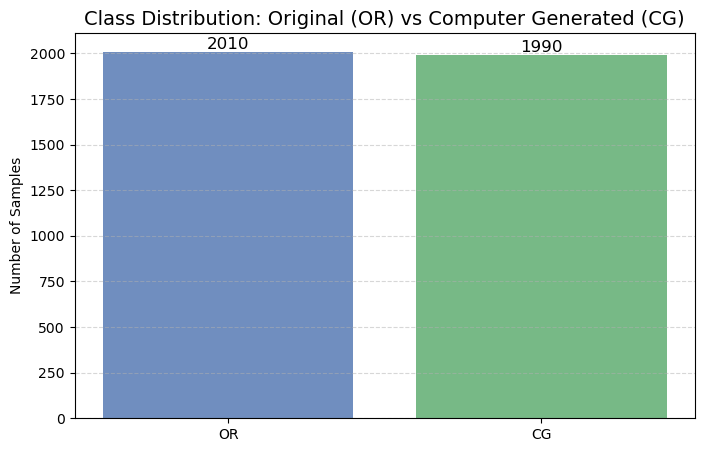

Corrected index: tfidf_svd_0 is at the 3th column, tfidf_svd_1 is at the 4th column
Saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\2_svd_visualization.png


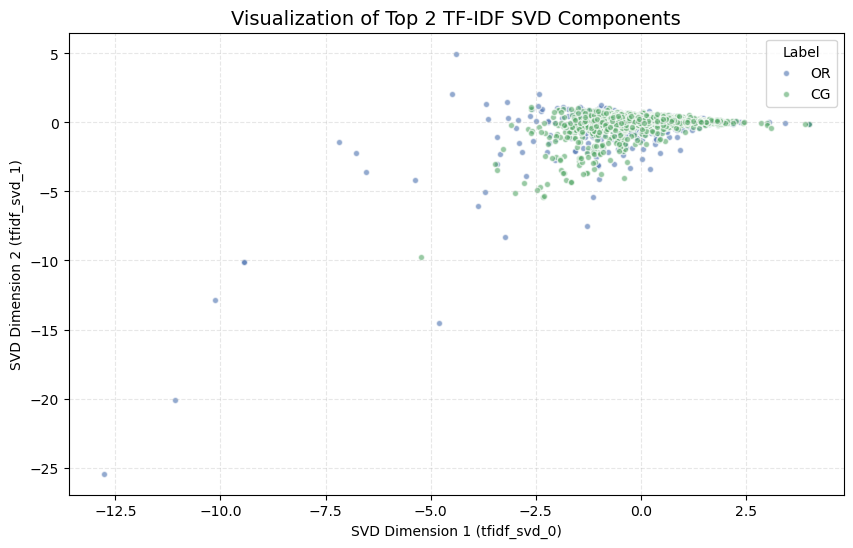

Saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\3_loss_curve.png


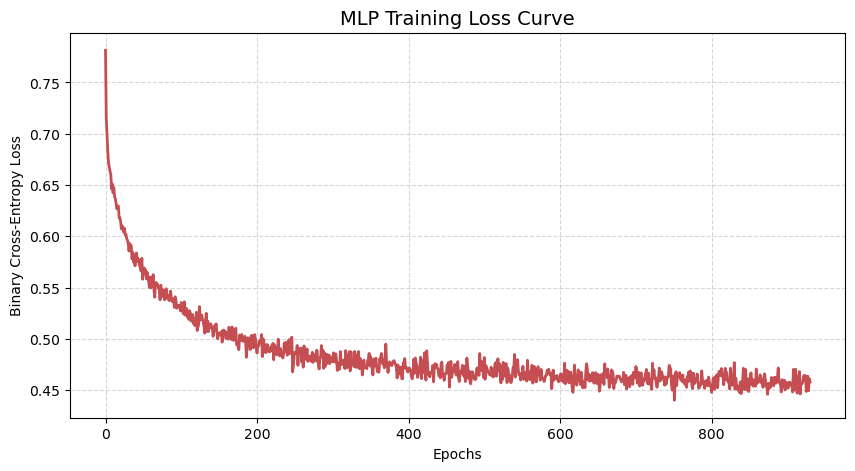

Saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\4_precision_curve.png


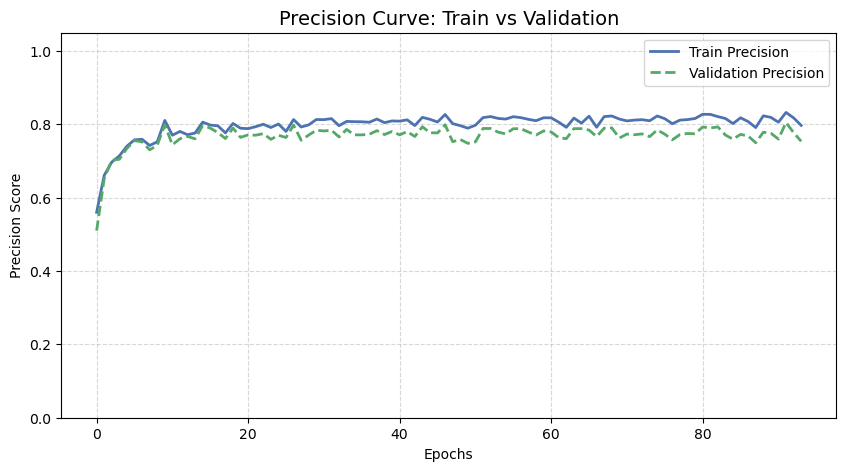

The best model (model_best.pkl) is being loaded for the final evaluation...


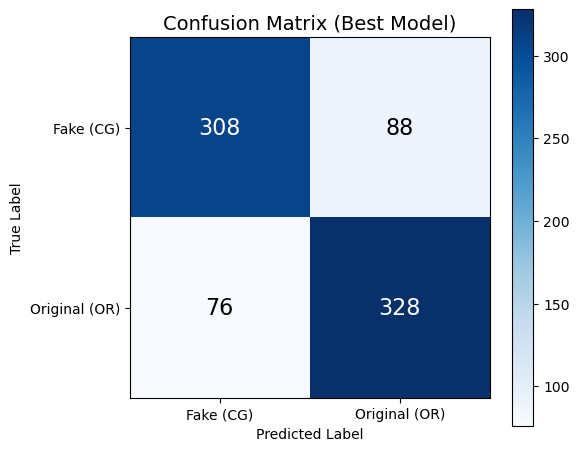

In [9]:
# The ninth step: Evaluation & Visualization
# ==========================================
# 4. Training & Evaluation
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

# Make sure the output directory exists
output_dir = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ---------------------------------------------------------
# Instantiate the model
# ---------------------------------------------------------
print("Initializing model...")
input_dim = X_train.shape[1]
# Create a new instance of the model and ensure that it is trained from scratch.
model = SimpleMLP(input_size=input_dim, learning_rate=0.001, momentum=0.9, reg_lambda=0.001)

# 4.1 Start Training
print("Start training the neural network...")
history = model.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32)

# 4.2 Prediction
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


# 4.3 Print out the evaluation Metrics
def calculate_metrics(y_true, y_pred, dataset_name="Test"):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"--- {dataset_name} Set Metrics ---\n")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\n")


calculate_metrics(y_train, y_pred_train, "Training")
calculate_metrics(y_test, y_pred_test, "Test")


# Set the drawing style
plt.style.use('default')

# ==============================================================================
# Chart 1: Data Class Balance Distribution
# ==============================================================================
temp_df = pd.DataFrame({'label': np.where(y_train.flatten()==1, 'OR', 'CG')})
temp_df_test = pd.DataFrame({'label': np.where(y_test.flatten()==1, 'OR', 'CG')})
combined_labels = pd.concat([temp_df, temp_df_test])

plt.figure(figsize=(8, 5))
label_counts = combined_labels['label'].value_counts()
colors = ['#4c72b0', '#55a868'] 

bars = plt.bar(label_counts.index, label_counts.values, color=colors, alpha=0.8)
plt.title('Class Distribution: Original (OR) vs Computer Generated (CG)', fontsize=14)
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12)
save_path_1 = os.path.join(output_dir, '1_class_distribution.png')
plt.savefig(save_path_1, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path_1}")
plt.show()

# ==============================================================================
# Chart 2: SVD Feature Scatter Plot
# ==============================================================================
# Find the positions of tfidf_svd_0 and tfidf_svd_1 in the feature list
idx_svd0 = feature_cols.index('tfidf_svd_0')
idx_svd1 = feature_cols.index('tfidf_svd_1')

print(f"Corrected index: tfidf_svd_0 is at the {idx_svd0}th column, tfidf_svd_1 is at the {idx_svd1}th column")

plt.figure(figsize=(10, 6))

# Extract data using the correct index.
svd_x = X_train[:, idx_svd0] 
svd_y = X_train[:, idx_svd1]

# Here, y_train is an array of shape (N, 1), which is flattened for plotting purposes.
labels_flat = y_train.flatten()

# Draw scatter plot
# OR (1) -> Blue, CG (0) -> Green
plt.scatter(svd_x[labels_flat==1], svd_y[labels_flat==1],
            c='#4c72b0', label='OR', alpha=0.6, s=20, edgecolor='w')
plt.scatter(svd_x[labels_flat==0], svd_y[labels_flat==0],
            c='#55a868', label='CG', alpha=0.6, s=20, edgecolor='w')

plt.title('Visualization of Top 2 TF-IDF SVD Components', fontsize=14)
plt.xlabel('SVD Dimension 1 (tfidf_svd_0)')
plt.ylabel('SVD Dimension 2 (tfidf_svd_1)')
plt.legend(title='Label')
plt.grid(True, linestyle='--', alpha=0.3)

save_path_2 = os.path.join(output_dir, '2_svd_visualization.png')
plt.savefig(save_path_2, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path_2}")
plt.show()

# ==============================================================================
# Chart 3: Loss Curve
# ==============================================================================
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], color='#c44e52', linewidth=2)
plt.title('MLP Training Loss Curve', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
save_path_3 = os.path.join(output_dir, '3_loss_curve.png')
plt.savefig(save_path_3, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path_3}")
plt.show()

# ==============================================================================
# Chart 4: Precision Curve
# ==============================================================================
plt.figure(figsize=(10, 5))
plt.plot(history['train_precision'], color='#4c72b0', linewidth=2, label='Train Precision')
plt.plot(history['val_precision'], color='#55a868', linewidth=2, linestyle='--', label='Validation Precision')
plt.title('Precision Curve: Train vs Validation', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Precision Score')
plt.legend()
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
save_path_4 = os.path.join(output_dir, '4_precision_curve.png')
plt.savefig(save_path_4, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path_4}")
plt.show()

# ==============================================================================
# Chart 5: Confusion Matrix (Best Model)
# ==============================================================================
print("The best model (model_best.pkl) is being loaded for the final evaluation...")
best_model_path = r"C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model\model_best.pkl"
try:
    model.load_model(best_model_path)
    
    y_pred_final = model.predict(X_test).flatten()
    y_true_final = y_test.flatten()

    tp = np.sum((y_true_final == 1) & (y_pred_final == 1))
    tn = np.sum((y_true_final == 0) & (y_pred_final == 0))
    fp = np.sum((y_true_final == 0) & (y_pred_final == 1))
    fn = np.sum((y_true_final == 1) & (y_pred_final == 0))
    cm = np.array([[tn, fp], [fn, tp]])

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix (Best Model)', fontsize=14)
    plt.colorbar()

    classes = ['Fake (CG)', 'Original (OR)']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center", fontsize=16,
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    save_path_5 = os.path.join(output_dir, '5_confusion_matrix_best.png')
    plt.savefig(save_path_5, dpi=300, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print(f"Warning: Best model file not found at {best_model_path}. Skipping confusion matrix plot.")

=== Start the Final Evaluation ===
The best model has been loaded.: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model\model_best.pkl

Processing Open Dataset (3k) (3000 samples)...
   -> [Result] F1: 0.7890, Acc: 0.7827

Processing Self Dataset (1000 samples)...
   -> [Result] F1: 0.8785, Acc: 0.8880

Processing the Mixed Dataset (All Data)...
   -> [Result] F1: 0.8096, Acc: 0.8090

Generate a comparison chart...
Charts have been saved: C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\6_final_comparison.png


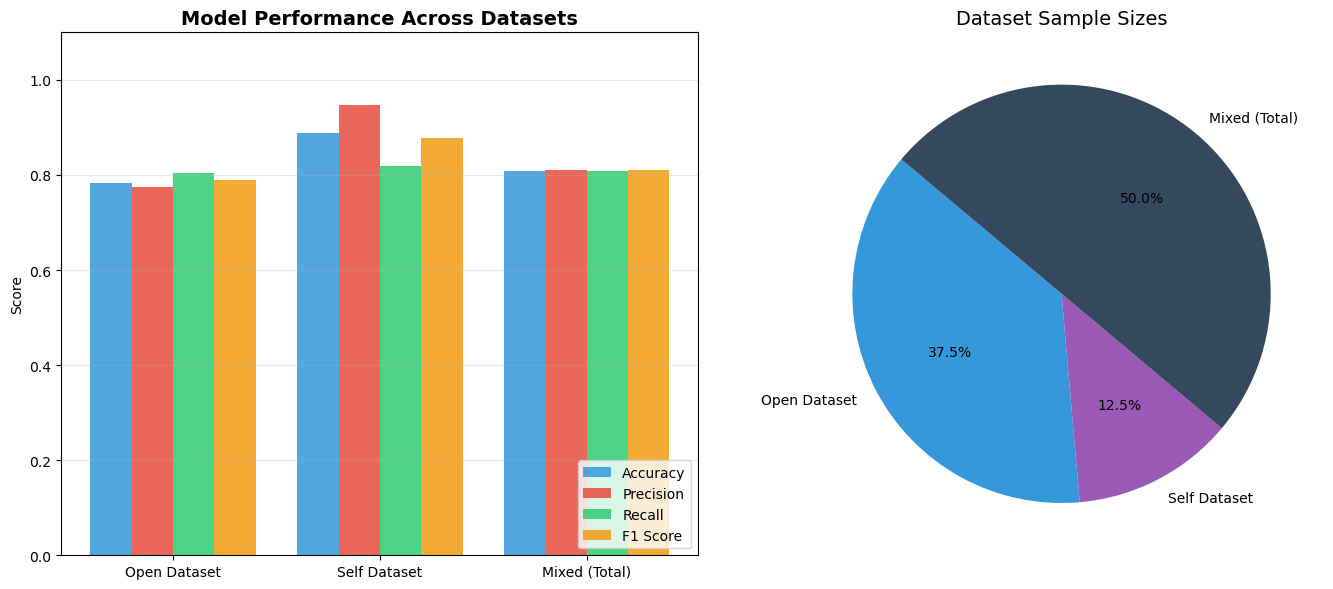


Dataset Name         Samples    Accuracy   Precision  Recall     F1        
---------------------------------------------------------------------------
Open Dataset         3000       0.7827     0.7745     0.8041     0.7890    
Self Dataset         1000       0.8880     0.9463     0.8198     0.8785    
Mixed (Total)        4000       0.8090     0.8112     0.8080     0.8096    


In [10]:
# The tenth step: Evaluate different datasets using the best model.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from collections import Counter

print("=== Start the Final Evaluation ===")

# ==========================================
# 0. Prepare the environment and model
# ==========================================
# Reinitialize the model structure
input_dim = X_train.shape[1]
model_best = SimpleMLP(input_size=input_dim, learning_rate=0.0003, momentum=0.9, reg_lambda=0.01)

# Load the best trained weights
best_model_path = r"C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\model\model_best.pkl"
if os.path.exists(best_model_path):
    model_best.load_model(best_model_path)
    print(f"The best model has been loaded.: {best_model_path}")
else:
    print("No optimal model file was found. Using the model currently stored in the memory.")

# ==========================================
# 1. Define the data transformation pipeline
# ==========================================
# Core function: It simulates the process of "inserting new data into a pre-trained system".
# The parameters learned from the training set (Cell 6) must be strictly used：word_to_index, idf_vector, Vt_k, X_mean, X_std
def transform_pipeline(df_raw, dataset_name):
    print(f"\nProcessing {dataset_name} ({len(df_raw)} samples)...")
    
    # 1. Text preprocessing
    df_raw['text'] = df_raw['text'].fillna('').astype(str)

    if 'rating' in df_raw.columns:
        rating = df_raw['rating'].values.reshape(-1, 1)
    else:
        print("The 'rating' column is missing. Fill it with 0.")
        rating = np.zeros((len(df_raw), 1))

    # 2. Extract manual features
    word_count = df_raw['text'].apply(lambda x: len(x.split())).values.reshape(-1, 1)
    excl_count = df_raw['text'].apply(lambda x: x.count('!')).values.reshape(-1, 1)
    
    # 3. Extract SVD features
    tokens_list = df_raw['text'].apply(clean_text).tolist()
    # Calculate TF-IDF and SVD using the parameters of Cell 6
    tf_mat, _ = compute_tf_matrix(tokens_list, word_to_index, n_vocab)
    tfidf_mat = tf_mat * idf_vector
    svd_mat = np.dot(tfidf_mat, Vt_k.T)

    # 4. Combine all features
    X_combined = np.hstack([rating, word_count, excl_count, svd_mat])

    
    # 5. Normalization
    try:
        X_final = (X_combined - X_mean) / X_std
    except ValueError as e:
        print(f"Normalization failed, dimensions do not match: {e}")
        return None, None
    
    # 6. Prepare labels
    y_final = np.where(df_raw['label'] == 'OR', 1, 0).reshape(-1, 1)
    
    return X_final, y_final

# ==========================================
# 2. Read and process three datasets
# ==========================================
results = []

# Define the evaluation function
def evaluate_and_record(name, X, y):
    preds = model_best.predict(X)
    tp = np.sum((y == 1) & (preds == 1))
    tn = np.sum((y == 0) & (preds == 0))
    fp = np.sum((y == 0) & (preds == 1))
    fn = np.sum((y == 1) & (preds == 0))
    
    acc = (tp + tn) / len(y)
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    
    results.append({
        'name': name, 'samples': len(y),
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1
    })
    print(f"   -> [Result] F1: {f1:.4f}, Acc: {acc:.4f}")

# --- Dataset A: Open Dataset ---
path_open = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\open_3k.csv'
if os.path.exists(path_open):
    df_open = pd.read_csv(path_open)
    X_open, y_open = transform_pipeline(df_open, "Open Dataset (3k)")
    evaluate_and_record("Open Dataset", X_open, y_open)
else:
    print(f"Can not find the file: {path_open}")

# --- Dataset B: Self Dataset ---
path_self = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\dataset\self_dataset_cleaned.csv'
if os.path.exists(path_self):
    df_self = pd.read_csv(path_self)
    X_self, y_self = transform_pipeline(df_self, "Self Dataset")
    evaluate_and_record("Self Dataset", X_self, y_self)
else:
    print(f"Can not find the file: {path_self}")

# --- Dataset C: Mixed Dataset (Training + Test) ---
# We can simply concatenate the data in the memory here, without having to re-read the file.
# Because processed_data_with_embeddings.csv is the combined set of X_train and X_test essentially.
print("\nProcessing the Mixed Dataset (All Data)...")
X_total = np.vstack([X_train, X_test])
y_total = np.vstack([y_train, y_test])
evaluate_and_record("Mixed (Total)", X_total, y_total)

# ==========================================
# 3. Visualized results
# ==========================================
print("\nGenerate a comparison chart...")
if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Figure 1: Bar Chart
    names = [r['name'] for r in results]
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    keys = ['accuracy', 'precision', 'recall', 'f1']
    
    x = np.arange(len(names))
    width = 0.2
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    for i, key in enumerate(keys):
        vals = [r[key] for r in results]
        axes[0].bar(x + i*width, vals, width, label=metrics[i], color=colors[i], alpha=0.85)
        
    axes[0].set_title('Model Performance Across Datasets', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score')
    axes[0].set_xticks(x + width * 1.5)
    axes[0].set_xticklabels(names)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(0, 1.1)
    
    # Figure 2: Pie Chart (Sample Size)
    samples = [r['samples'] for r in results]
    axes[1].pie(samples, labels=names, autopct='%1.1f%%', 
                colors=['#3498db', '#9b59b6', '#34495e'], startangle=140)
    axes[1].set_title('Dataset Sample Sizes', fontsize=14)
    
    plt.tight_layout()
    save_path = r'C:\Users\Zijie.Xue25\XZJ_PythonProjects\DTS402\output\6_final_comparison.png'
    plt.savefig(save_path, dpi=300)
    print(f"Charts have been saved: {save_path}")
    plt.show()

# ==========================================
# 4. Print the detailed table
# ==========================================
print("\n" + "="*75)
print(f"{'Dataset Name':<20} {'Samples':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 75)
for r in results:
    print(f"{r['name']:<20} {r['samples']:<10} {r['accuracy']:<10.4f} {r['precision']:<10.4f} {r['recall']:<10.4f} {r['f1']:<10.4f}")
print("="*75)